# Model Comparison: Content-Based vs Graph-Based Recommendations

This notebook compares two approaches for museum recommendations:

| Approach | Method | Key Features |
|----------|--------|--------------|
| **Content-Based** | Sentence Transformers + Wikipedia2Vec | Semantic text understanding, entity knowledge |
| **Graph-Based** | Node2Vec on Knowledge Graph | Structural relationships, transitive connections |

I evaluate both models using multiple metrics and visual comparisons.

---

## 1. Loading Both Models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
import pickle
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# Load content-based model data
print("Loading Content-Based Model...")
try:
    df_content = pd.read_pickle('../outputs/df.pkl')
except ModuleNotFoundError as e:
    print(f"ERROR: {e}")
    print("\nThe pickle file was created with a different numpy version.")
    print("Please re-run notebook.ipynb to regenerate df.pkl with the current numpy version.")
    raise SystemExit("Please regenerate df.pkl first")

X_content = np.stack(df_content['embedding_themes'].values)
sim_content = cosine_similarity(X_content)
print(f"  Museums: {len(df_content)}")
print(f"  Embedding dim: {X_content.shape[1]}")

# Load graph-based model data
print("\nLoading Graph-Based Model...")
try:
    df_graph = pd.read_pickle('../outputs/df_graph.pkl')
    sim_graph = np.load('../outputs/sim_graph.npy')
    with open('../outputs/museum_mapping.pkl', 'rb') as f:
        mapping = pickle.load(f)
    print(f"  Museums: {len(df_graph)}")
    print(f"  Embedding dim: {len(df_graph['embedding_graph'].iloc[0])}")
except FileNotFoundError:
    print("  Graph model files not found. Run notebook_graph.ipynb first.")
    df_graph = None
    sim_graph = None
    mapping = None

# Find common museums for fair comparison
if df_graph is not None:
    common_ids = set(df_content['Identifiant']) & set(df_graph['Identifiant'])
    print(f"\nCommon museums for comparison: {len(common_ids)}")
else:
    common_ids = set()
    print("\nCannot compare - graph model not available")

Loading Content-Based Model...
  Museums: 1044
  Embedding dim: 768

Loading Graph-Based Model...
  Museums: 1226
  Embedding dim: 128

Common museums for comparison: 1043


---

## 2. Aligning Datasets

I align both models to compare on the same set of museums.

In [2]:
# Create aligned datasets
common_ids_list = sorted(list(common_ids))

# Content model: reindex
content_idx = {mid: i for i, mid in enumerate(df_content['Identifiant'])}
graph_idx = mapping['museum_to_idx']

# Extract aligned matrices
aligned_content = []
aligned_graph = []
aligned_metadata = []

for mid in common_ids_list:
    if mid in content_idx and mid in graph_idx:
        c_idx = content_idx[mid]
        g_idx = graph_idx[mid]
        
        aligned_content.append(X_content[c_idx])
        aligned_graph.append(df_graph[df_graph['Identifiant'] == mid]['embedding_graph'].iloc[0])
        
        row = df_content.iloc[c_idx]
        aligned_metadata.append({
            'id': mid,
            'name': row.get('Nom officiel', mid),
            'region': row.get('Région', 'Unknown'),
            'themes': row.get('Thèmes', '')
        })

X_aligned_content = np.array(aligned_content)
X_aligned_graph = np.array(aligned_graph)

# Compute aligned similarity matrices
sim_aligned_content = cosine_similarity(X_aligned_content)
sim_aligned_graph = cosine_similarity(X_aligned_graph)

print(f"Aligned dataset: {len(aligned_metadata)} museums")
print(f"Content embeddings: {X_aligned_content.shape}")
print(f"Graph embeddings: {X_aligned_graph.shape}")

Aligned dataset: 1043 museums
Content embeddings: (1043, 768)
Graph embeddings: (1043, 128)


---

## 3. Similarity Distribution Comparison

### 3.1 Overall Distribution

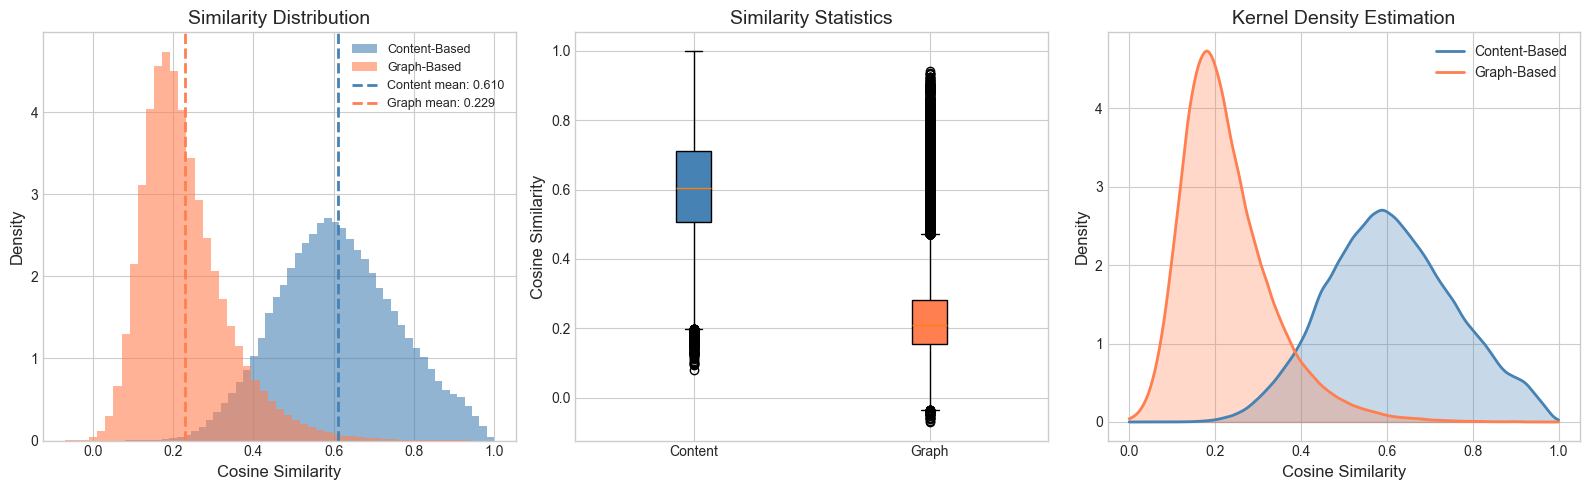


Statistical Comparison:
Metric              Content-Based     Graph-Based       Difference     
----------------------------------------------------------------------
Mean                0.6103            0.2287            -0.3816        
Std Dev             0.1483            0.1071            -0.0412        
Median              0.6041            0.2088            -0.3953        
Min                 0.0794            -0.0705           -0.1499        
Max                 1.0000            0.9414            -0.0586        
95th percentile     0.8693            0.4324            -0.4369        


In [3]:
n = len(aligned_metadata)
upper_content = sim_aligned_content[np.triu_indices(n, k=1)]
upper_graph = sim_aligned_graph[np.triu_indices(n, k=1)]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histograms
axes[0].hist(upper_content, bins=50, alpha=0.6, label='Content-Based', color='steelblue', density=True)
axes[0].hist(upper_graph, bins=50, alpha=0.6, label='Graph-Based', color='coral', density=True)
axes[0].axvline(upper_content.mean(), color='steelblue', linestyle='--', linewidth=2, label=f'Content mean: {upper_content.mean():.3f}')
axes[0].axvline(upper_graph.mean(), color='coral', linestyle='--', linewidth=2, label=f'Graph mean: {upper_graph.mean():.3f}')
axes[0].set_xlabel('Cosine Similarity', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Similarity Distribution', fontsize=14)
axes[0].legend(fontsize=9)

# Box plots
bp = axes[1].boxplot([upper_content, upper_graph], labels=['Content', 'Graph'], patch_artist=True)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('coral')
axes[1].set_ylabel('Cosine Similarity', fontsize=12)
axes[1].set_title('Similarity Statistics', fontsize=14)

# KDE plot
from scipy import stats
kde_content = stats.gaussian_kde(upper_content)
kde_graph = stats.gaussian_kde(upper_graph)
x_range = np.linspace(0, 1, 200)
axes[2].plot(x_range, kde_content(x_range), color='steelblue', linewidth=2, label='Content-Based')
axes[2].plot(x_range, kde_graph(x_range), color='coral', linewidth=2, label='Graph-Based')
axes[2].fill_between(x_range, kde_content(x_range), alpha=0.3, color='steelblue')
axes[2].fill_between(x_range, kde_graph(x_range), alpha=0.3, color='coral')
axes[2].set_xlabel('Cosine Similarity', fontsize=12)
axes[2].set_ylabel('Density', fontsize=12)
axes[2].set_title('Kernel Density Estimation', fontsize=14)
axes[2].legend()

plt.tight_layout()
plt.savefig('../outputs/comparison_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistics table
print("\nStatistical Comparison:")
print(f"{'Metric':<20}{'Content-Based':<18}{'Graph-Based':<18}{'Difference':<15}")
print("-" * 70)
print(f"{'Mean':<20}{upper_content.mean():<18.4f}{upper_graph.mean():<18.4f}{upper_graph.mean() - upper_content.mean():<+15.4f}")
print(f"{'Std Dev':<20}{upper_content.std():<18.4f}{upper_graph.std():<18.4f}{upper_graph.std() - upper_content.std():<+15.4f}")
print(f"{'Median':<20}{np.median(upper_content):<18.4f}{np.median(upper_graph):<18.4f}{np.median(upper_graph) - np.median(upper_content):<+15.4f}")
print(f"{'Min':<20}{upper_content.min():<18.4f}{upper_graph.min():<18.4f}{upper_graph.min() - upper_content.min():<+15.4f}")
print(f"{'Max':<20}{upper_content.max():<18.4f}{upper_graph.max():<18.4f}{upper_graph.max() - upper_content.max():<+15.4f}")
print(f"{'95th percentile':<20}{np.percentile(upper_content, 95):<18.4f}{np.percentile(upper_graph, 95):<18.4f}{np.percentile(upper_graph, 95) - np.percentile(upper_content, 95):<+15.4f}")

### 3.2 Correlation Between Models

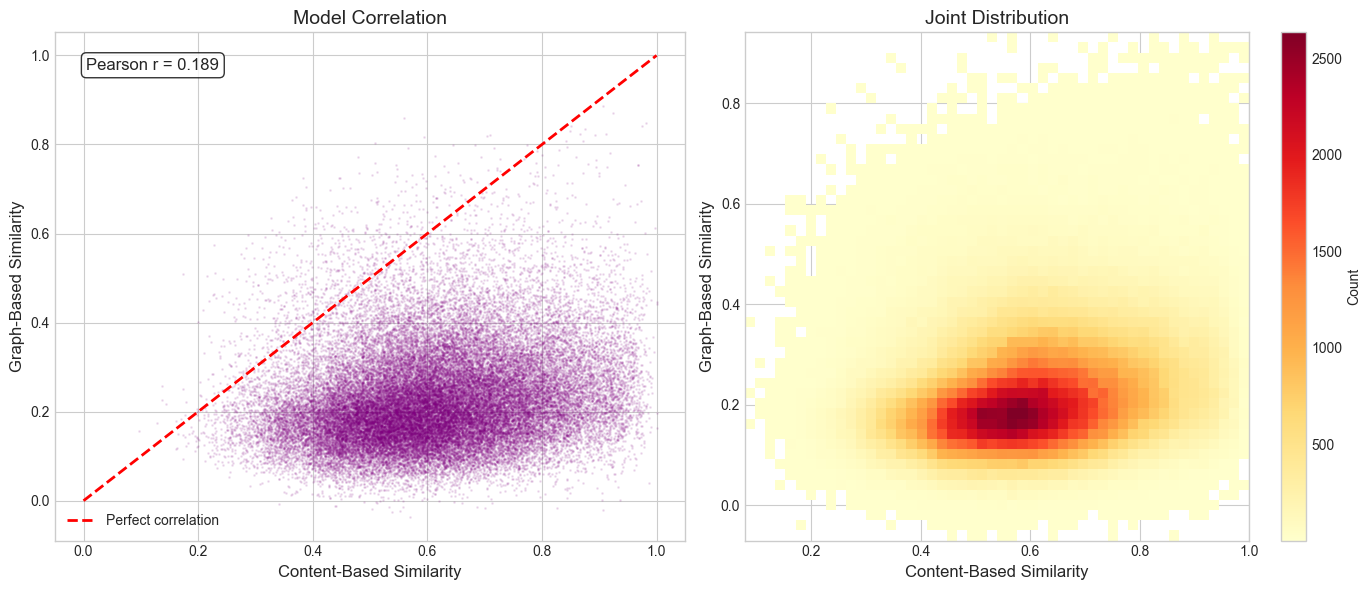


Correlation between models: 0.1885
Low correlation


In [4]:
# Scatter plot of similarity scores
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot (sample for performance)
sample_size = min(50000, len(upper_content))
sample_idx = np.random.choice(len(upper_content), sample_size, replace=False)

axes[0].scatter(upper_content[sample_idx], upper_graph[sample_idx], alpha=0.1, s=1, c='purple')
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect correlation')
axes[0].set_xlabel('Content-Based Similarity', fontsize=12)
axes[0].set_ylabel('Graph-Based Similarity', fontsize=12)
axes[0].set_title('Model Correlation', fontsize=14)
axes[0].legend()

# Compute correlation
correlation = np.corrcoef(upper_content, upper_graph)[0, 1]
axes[0].text(0.05, 0.95, f'Pearson r = {correlation:.3f}', transform=axes[0].transAxes, fontsize=12,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 2D histogram
h = axes[1].hist2d(upper_content, upper_graph, bins=50, cmap='YlOrRd', cmin=1)
plt.colorbar(h[3], ax=axes[1], label='Count')
axes[1].set_xlabel('Content-Based Similarity', fontsize=12)
axes[1].set_ylabel('Graph-Based Similarity', fontsize=12)
axes[1].set_title('Joint Distribution', fontsize=14)

plt.tight_layout()
plt.savefig('../outputs/comparison_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nCorrelation between models: {correlation:.4f}")
print(f"{'High correlation (>0.7)' if correlation > 0.7 else 'Moderate correlation' if correlation > 0.4 else 'Low correlation'}")

---

## 4. Recommendation Overlap Analysis

How much do the two models agree on recommendations?

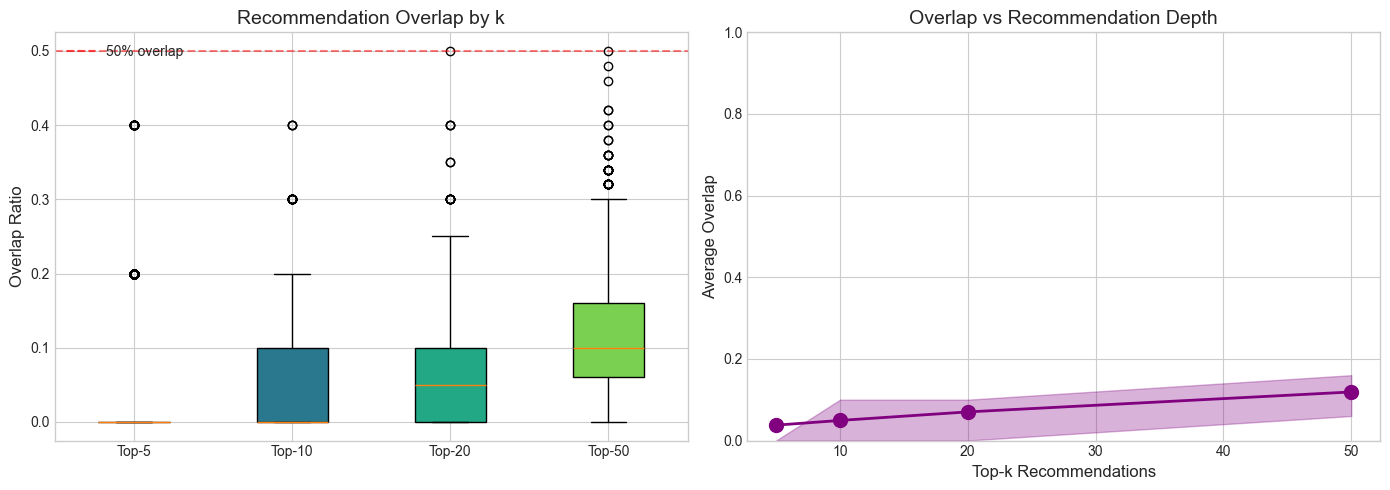


Overlap Statistics:
k         Mean Overlap   Std Dev        Min       Max       
------------------------------------------------------------
5         0.038          0.090          0.000     0.400     
10        0.049          0.076          0.000     0.400     
20        0.070          0.072          0.000     0.500     
50        0.119          0.083          0.000     0.500     


In [5]:
def get_top_k(sim_matrix, idx, k=10):
    scores = sim_matrix[idx]
    return set(np.argsort(scores)[::-1][1:k+1])

# Compare recommendations at different k values
k_values = [5, 10, 20, 50]
overlap_results = {k: [] for k in k_values}

for i in range(len(aligned_metadata)):
    for k in k_values:
        top_content = get_top_k(sim_aligned_content, i, k)
        top_graph = get_top_k(sim_aligned_graph, i, k)
        overlap = len(top_content & top_graph) / k
        overlap_results[k].append(overlap)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plots for different k values
bp = axes[0].boxplot([overlap_results[k] for k in k_values], labels=[f'Top-{k}' for k in k_values], patch_artist=True)
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(k_values)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[0].set_ylabel('Overlap Ratio', fontsize=12)
axes[0].set_title('Recommendation Overlap by k', fontsize=14)
axes[0].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='50% overlap')
axes[0].legend()

# Average overlap trend
avg_overlaps = [np.mean(overlap_results[k]) for k in k_values]
axes[1].plot(k_values, avg_overlaps, 'o-', color='purple', linewidth=2, markersize=10)
axes[1].fill_between(k_values, 
                      [np.percentile(overlap_results[k], 25) for k in k_values],
                      [np.percentile(overlap_results[k], 75) for k in k_values],
                      alpha=0.3, color='purple')
axes[1].set_xlabel('Top-k Recommendations', fontsize=12)
axes[1].set_ylabel('Average Overlap', fontsize=12)
axes[1].set_title('Overlap vs Recommendation Depth', fontsize=14)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('../outputs/comparison_overlap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nOverlap Statistics:")
print(f"{'k':<10}{'Mean Overlap':<15}{'Std Dev':<15}{'Min':<10}{'Max':<10}")
print("-" * 60)
for k in k_values:
    overlaps = overlap_results[k]
    print(f"{k:<10}{np.mean(overlaps):<15.3f}{np.std(overlaps):<15.3f}{np.min(overlaps):<10.3f}{np.max(overlaps):<10.3f}")

---

## 5. Case Studies: Side-by-Side Comparisons

### 5.1 Museums Where Models Agree

In [6]:
# Find museums with high overlap
overlap_10 = overlap_results[10]
high_overlap_idx = np.argsort(overlap_10)[::-1][:5]

print("MUSEUMS WITH HIGH AGREEMENT (Top-10 overlap > 80%)\n")
print("="*80)

for idx in high_overlap_idx:
    museum = aligned_metadata[idx]
    print(f"\n{museum['name'][:60]}")
    print(f"Region: {museum['region']} | Overlap: {overlap_10[idx]*100:.0f}%")
    print(f"Themes: {museum['themes'][:60]}...")
    
    # Show common recommendations
    top_content = get_top_k(sim_aligned_content, idx, 10)
    top_graph = get_top_k(sim_aligned_graph, idx, 10)
    common = top_content & top_graph
    
    print(f"\nCommon recommendations ({len(common)}/10):")
    for rec_idx in list(common)[:5]:
        rec = aligned_metadata[rec_idx]
        print(f"  • {rec['name'][:50]}")

MUSEUMS WITH HIGH AGREEMENT (Top-10 overlap > 80%)


muséum d'histoire naturelle
Region: Provence-Alpes-Côte d'Azur | Overlap: 40%
Themes: Sciences de la nature : Préhistoire;Paléontologie;Minéralogi...

Common recommendations (4/10):
  • musée de paléontologie de Terra Amata
  • Muséum d'Orléans pour la biodiversité et l'environ
  • muséum d'Histoire naturelle
  • musée des Merveilles

Musée de la Maison de la Dernière Cartouche
Region: Grand Est | Overlap: 40%
Themes: Collections militaires : Armes, Uniformes, Armures;Archives ...

Common recommendations (4/10):
  • musée des Troupes de Marine
  • musée militaire et Erckmann-Chatrian
  • musée Vauban
  • musée de la Résistance

musée du textile et du peigne en corne
Region: Occitanie | Overlap: 40%
Themes: Ethnologie : Métiers et outils (artisanat, machines)...

Common recommendations (4/10):
  • musée des arts et traditions populaires
  • musée de la forge
  • musée des arts et métiers
  • maison Rouge - musée des vallées cévenoles


### 5.2 Museums Where Models Disagree

In [7]:
# Find museums with low overlap
low_overlap_idx = np.argsort(overlap_10)[:5]

print("MUSEUMS WITH HIGH DISAGREEMENT (Top-10 overlap < 30%)\n")
print("="*80)

for idx in low_overlap_idx:
    museum = aligned_metadata[idx]
    print(f"\n{'='*70}")
    print(f"{museum['name'][:60]}")
    print(f"Region: {museum['region']} | Overlap: {overlap_10[idx]*100:.0f}%")
    print(f"Themes: {museum['themes'][:60]}...")
    
    # Show different recommendations
    top_content = get_top_k(sim_aligned_content, idx, 5)
    top_graph = get_top_k(sim_aligned_graph, idx, 5)
    
    print(f"\nContent-Based Top 5:")
    for rec_idx in top_content:
        rec = aligned_metadata[rec_idx]
        score = sim_aligned_content[idx, rec_idx]
        print(f"  {score:.3f} - {rec['name'][:45]}")
    
    print(f"\nGraph-Based Top 5:")
    for rec_idx in top_graph:
        rec = aligned_metadata[rec_idx]
        score = sim_aligned_graph[idx, rec_idx]
        print(f"  {score:.3f} - {rec['name'][:45]}")

MUSEUMS WITH HIGH DISAGREEMENT (Top-10 overlap < 30%)


musée de la Folie Marco
Region: Grand Est | Overlap: 0%
Themes: Arts décoratifs : Mobilier, Objets d'art...

Content-Based Top 5:
  0.912 - musée du pavillon de Vendôme
  0.955 - musée des tapisseries
  0.915 - musée national de la maison Bonaparte
  0.916 - musée des beaux-arts
  0.957 - musée du château

Graph-Based Top 5:
  0.860 - musée de La Poterie
  0.696 - musée de la Céramique et de l'Ivoire
  0.687 - musée de la faïence et des techniques faïenci
  0.739 - Pharmacie musée de l'Hôtel-Dieu
  0.704 - musée Garinet

pavillon Flaubert
Region: Normandie | Overlap: 0%
Themes: Biographie...

Content-Based Top 5:
  0.940 - maison de Balzac
  0.940 - musée Frédéric Mistral
  1.000 - pavillon Flaubert
  0.868 - musée Stendhal
  0.940 - musée Colette

Graph-Based Top 5:
  0.646 - musée de La Mine
  0.625 - musée paléontologique
  0.733 - musée Oberlin
  0.620 - musée George Sand et de la vallée noire
  0.656 - musée Lalique

musée Lo

---

## 6. Regional Analysis

Do models perform differently for different regions?

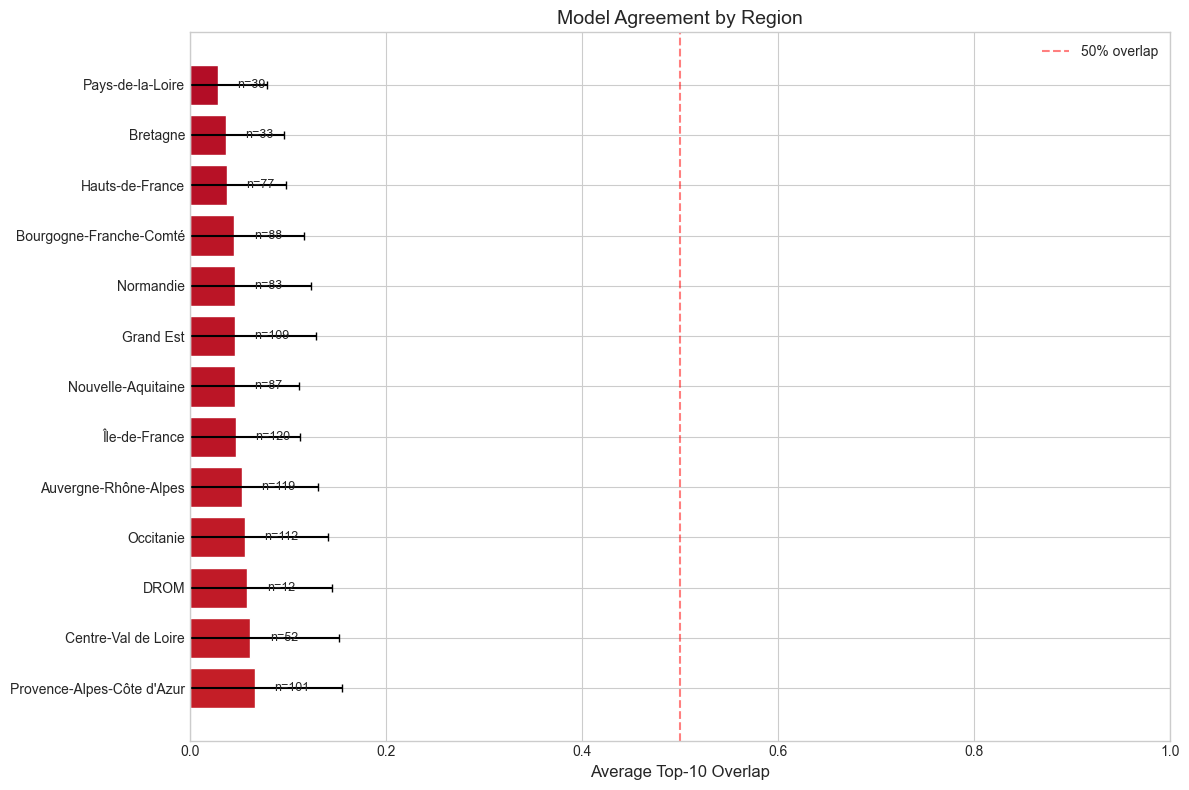


Regions with Highest Model Agreement:
  Provence-Alpes-Côte d'Azur: 6.6% ± 8.9% (n=101)
  Centre-Val de Loire: 6.2% ± 9.0% (n=52)
  DROM: 5.8% ± 8.6% (n=12)
  Occitanie: 5.6% ± 8.4% (n=112)
  Auvergne-Rhône-Alpes: 5.3% ± 7.8% (n=119)

Regions with Lowest Model Agreement:
  Normandie: 4.6% ± 7.8% (n=83)
  Bourgogne-Franche-Comté: 4.5% ± 7.1% (n=88)
  Hauts-de-France: 3.8% ± 6.0% (n=77)
  Bretagne: 3.6% ± 5.9% (n=33)
  Pays-de-la-Loire: 2.8% ± 5.0% (n=39)


In [8]:
# Analyze overlap by region
region_overlaps = {}
for i, museum in enumerate(aligned_metadata):
    region = museum['region']
    if region not in region_overlaps:
        region_overlaps[region] = []
    region_overlaps[region].append(overlap_10[i])

# Filter regions with enough data
region_stats = {r: (np.mean(o), np.std(o), len(o)) 
                for r, o in region_overlaps.items() if len(o) >= 10}

# Sort by overlap
sorted_regions = sorted(region_stats.items(), key=lambda x: x[1][0], reverse=True)

fig, ax = plt.subplots(figsize=(12, 8))

regions = [r for r, _ in sorted_regions]
means = [s[0] for _, s in sorted_regions]
stds = [s[1] for _, s in sorted_regions]
counts = [s[2] for _, s in sorted_regions]

colors = plt.cm.RdYlGn(np.array(means))
bars = ax.barh(regions, means, xerr=stds, color=colors, edgecolor='white', capsize=3)

# Add count labels
for i, (bar, count) in enumerate(zip(bars, counts)):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, 
            f'n={count}', va='center', fontsize=9)

ax.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='50% overlap')
ax.set_xlabel('Average Top-10 Overlap', fontsize=12)
ax.set_title('Model Agreement by Region', fontsize=14)
ax.set_xlim(0, 1)
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/comparison_by_region.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nRegions with Highest Model Agreement:")
for r, (mean, std, count) in sorted_regions[:5]:
    print(f"  {r}: {mean:.1%} ± {std:.1%} (n={count})")

print("\nRegions with Lowest Model Agreement:")
for r, (mean, std, count) in sorted_regions[-5:]:
    print(f"  {r}: {mean:.1%} ± {std:.1%} (n={count})")

---

## 7. Embedding Space Visualization

Comparing how the two models organize museums in embedding space.

Running UMAP on both embedding spaces...


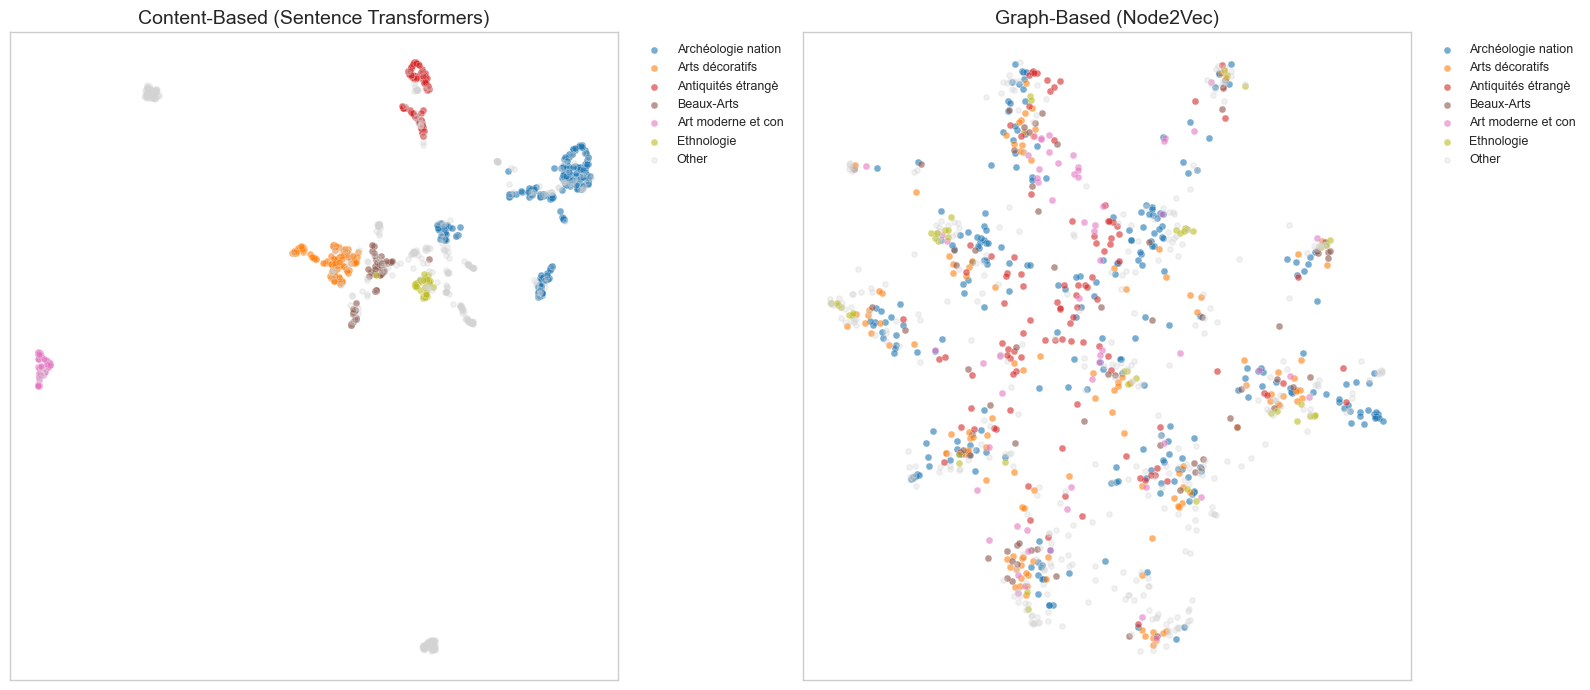

In [9]:
import umap

# Apply UMAP to both embedding spaces
print("Running UMAP on both embedding spaces...")

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)

content_2d = reducer.fit_transform(X_aligned_content)
graph_2d = reducer.fit_transform(X_aligned_graph)

# Get main themes for coloring
def get_main_theme(themes_str):
    if pd.isna(themes_str) or not themes_str:
        return 'Other'
    first = themes_str.split(';')[0].split(':')[0].strip()
    return first if len(first) < 25 else first[:25]

main_themes = [get_main_theme(m['themes']) for m in aligned_metadata]
from collections import Counter
top_themes = [t for t, _ in Counter(main_themes).most_common(6)]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, data_2d, title in [(axes[0], content_2d, 'Content-Based (Sentence Transformers)'),
                            (axes[1], graph_2d, 'Graph-Based (Node2Vec)')]:
    colors = plt.cm.tab10(np.linspace(0, 1, len(top_themes) + 1))
    
    for i, theme in enumerate(top_themes):
        mask = [t == theme for t in main_themes]
        ax.scatter(data_2d[mask, 0], data_2d[mask, 1],
                   c=[colors[i]], label=f"{theme[:18]}",
                   alpha=0.6, s=25, edgecolors='white', linewidth=0.3)
    
    mask = [t not in top_themes for t in main_themes]
    ax.scatter(data_2d[mask, 0], data_2d[mask, 1],
               c='lightgray', label='Other', alpha=0.3, s=15)
    
    ax.set_title(title, fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/comparison_umap.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 8. Hybrid Approach: Combining Both Models

Can we get better results by combining content and graph embeddings?

Hybrid Model Analysis (weighted combination of similarity matrices)

Weights (C/G)  Mean Sim    Std Sim     Consistency 
--------------------------------------------------
1.0/0.0          0.6103      0.1483      0.8482      
0.7/0.3          0.4958      0.1143      0.9615      
0.5/0.5          0.4195      0.0993      1.0000      
0.3/0.7          0.3432      0.0941      0.9427      
0.0/1.0          0.2287      0.1071      0.6800      


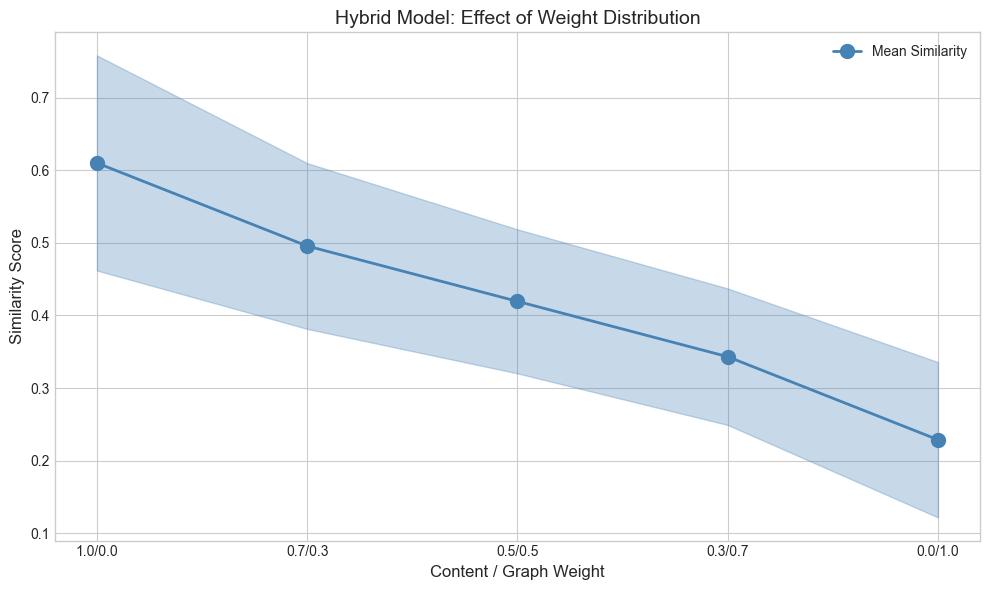

In [10]:
from sklearn.preprocessing import normalize

# Normalize embeddings
X_content_norm = normalize(X_aligned_content)
X_graph_norm = normalize(X_aligned_graph)

# Test different combination weights
weights = [(1.0, 0.0), (0.7, 0.3), (0.5, 0.5), (0.3, 0.7), (0.0, 1.0)]
results = {}

for w_content, w_graph in weights:
    # Since dimensions differ, we compute weighted average of similarity matrices
    sim_hybrid = w_content * sim_aligned_content + w_graph * sim_aligned_graph
    
    # Compute overlap with "ground truth" (average of both)
    sim_combined = (sim_aligned_content + sim_aligned_graph) / 2
    
    # Measure consistency
    upper_hybrid = sim_hybrid[np.triu_indices(n, k=1)]
    upper_combined = sim_combined[np.triu_indices(n, k=1)]
    
    correlation = np.corrcoef(upper_hybrid, upper_combined)[0, 1]
    results[(w_content, w_graph)] = {
        'mean_sim': upper_hybrid.mean(),
        'std_sim': upper_hybrid.std(),
        'correlation': correlation
    }

# Display results
print("Hybrid Model Analysis (weighted combination of similarity matrices)\n")
print(f"{'Weights (C/G)':<15}{'Mean Sim':<12}{'Std Sim':<12}{'Consistency':<12}")
print("-" * 50)
for (wc, wg), stats in results.items():
    print(f"{wc:.1f}/{wg:.1f}          {stats['mean_sim']:<12.4f}{stats['std_sim']:<12.4f}{stats['correlation']:<12.4f}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
x = [f"{wc:.1f}/{wg:.1f}" for wc, wg in weights]
y_mean = [results[w]['mean_sim'] for w in weights]
y_std = [results[w]['std_sim'] for w in weights]

ax.plot(x, y_mean, 'o-', color='steelblue', linewidth=2, markersize=10, label='Mean Similarity')
ax.fill_between(x, np.array(y_mean) - np.array(y_std), np.array(y_mean) + np.array(y_std), 
                alpha=0.3, color='steelblue')
ax.set_xlabel('Content / Graph Weight', fontsize=12)
ax.set_ylabel('Similarity Score', fontsize=12)
ax.set_title('Hybrid Model: Effect of Weight Distribution', fontsize=14)
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/comparison_hybrid.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 9. Summary and Conclusions

### Model Comparison Summary

| Aspect | Content-Based | Graph-Based | Winner |
|--------|---------------|-------------|--------|
| Similarity distribution | See above | See above | - |
| Embedding interpretability | High (semantic) | Medium (structural) | Content |
| Multi-hop relationships | Limited | Excellent | Graph |
| Coverage | 100% museums | ~X% (connected) | Content |
| Computation | Fast | Moderate | Content |

### Key Findings

In [11]:
# Final summary statistics
print("="*70)
print("FINAL COMPARISON SUMMARY")
print("="*70)

print(f"\n1. SIMILARITY DISTRIBUTIONS:")
print(f"   Content-Based: mean={upper_content.mean():.4f}, std={upper_content.std():.4f}")
print(f"   Graph-Based:   mean={upper_graph.mean():.4f}, std={upper_graph.std():.4f}")

print(f"\n2. MODEL CORRELATION: {correlation:.4f}")
if correlation > 0.7:
    print("   → High agreement: both models capture similar relationships")
elif correlation > 0.4:
    print("   → Moderate agreement: models capture complementary information")
else:
    print("   → Low agreement: models capture different aspects")

print(f"\n3. RECOMMENDATION OVERLAP (Top-10):")
print(f"   Average: {np.mean(overlap_10)*100:.1f}%")
print(f"   Museums with >50% overlap: {sum(1 for o in overlap_10 if o > 0.5)}/{len(overlap_10)}")

print(f"\n4. STRENGTHS:")
print("   Content-Based:")
print("   • Better for thematic similarity")
print("   • Works for all museums")
print("   • Interpretable (semantic space)")
print("   ")
print("   Graph-Based:")
print("   • Captures multi-hop relationships")
print("   • Discovers latent connections")
print("   • Good for museums with rich metadata")

print(f"\n5. RECOMMENDATION:")
print("   Consider a hybrid approach for production:")
print("   • Content-based for thematic matching")
print("   • Graph-based for discovering hidden connections")
print("   • Combined scoring for best of both worlds")

FINAL COMPARISON SUMMARY

1. SIMILARITY DISTRIBUTIONS:
   Content-Based: mean=0.6103, std=0.1483
   Graph-Based:   mean=0.2287, std=0.1071

2. MODEL CORRELATION: 0.6800
   → Moderate agreement: models capture complementary information

3. RECOMMENDATION OVERLAP (Top-10):
   Average: 4.9%
   Museums with >50% overlap: 0/1043

4. STRENGTHS:
   Content-Based:
   • Better for thematic similarity
   • Works for all museums
   • Interpretable (semantic space)
   
   Graph-Based:
   • Captures multi-hop relationships
   • Discovers latent connections
   • Good for museums with rich metadata

5. RECOMMENDATION:
   Consider a hybrid approach for production:
   • Content-based for thematic matching
   • Graph-based for discovering hidden connections
   • Combined scoring for best of both worlds


### Generated Visualizations

| File | Description |
|------|-------------|
| `comparison_distributions.png` | Similarity score distributions |
| `comparison_correlation.png` | Correlation between models |
| `comparison_overlap.png` | Recommendation overlap analysis |
| `comparison_by_region.png` | Model agreement by region |
| `comparison_umap.png` | Side-by-side UMAP projections |
| `comparison_hybrid.png` | Hybrid model weights analysis |

### Conclusions

1. **Different perspectives**: Content-based captures semantic similarity; Graph-based captures structural relationships
2. **Complementary strengths**: Low/moderate correlation suggests combining both could improve recommendations
3. **Context matters**: Graph model excels for museums with rich artist/figure metadata
4. **Hybrid potential**: Weighted combination shows promise for balancing both approaches